In [1]:
import numpy as np
import sys
sys.path.append("..") 
import utils.funciones as fm
import matplotlib.pyplot as plt

**CARGANDO DATOS**

In [2]:
# VARIABLES
user_float = np.float64
G_const = 4*(np.pi)**2  # Gravitational constant (AU^3/(M_sun*year^2)))
dt_const = 0.0005
mass = np.array([
    1988410E24,     #Sun
    3.302E23,       #Mercury
    48.685E23,      #Venus
    5.97219E24,     #Earth
    6.4171E23,      #Mars
    18.9819E26,     #Jupiter
    5.6834E26,      #Saturn
    86.813E24,      #Uranus
    102.409E24,     #Neptune
    1.303E22        #Pluto
    ], dtype=user_float)/1988410E24

r = np.load(r"../results/positions.npz")['pos']
p = np.load(r"../results/momenta.npz")['mon']

print(r.shape, p.shape)

(20000001, 10, 3) (20000001, 10, 3)


The Hamiltonian of the $N=10$ gravitational body system in three dimensions is defined as the sum of kinetic energy and potential energy,

$$H(\mathbf{z}) = H(\mathbf{r},\mathbf{p}) = T(\mathbf{p}) + V(\mathbf{r}),$$

where the state vector is

$$\mathbf{z} = (\mathbf{r},\mathbf{p}) \in \mathbb{R}^{60}.$$

### Kinetic Energy

Kinetic energy depends solely on linear momenta and is expressed as

$$T(\mathbf{p}) = \sum_{i=1}^{10} \frac{\|\mathbf{p}_i\|^2}{2 m_i},$$

with

$$\mathbf{p}_i = (p_{x_i}, p_{y_i}, p_{z_i}) \in \mathbb{R}^3.$$

### Gravitational Potential Energy

Gravitational potential energy depends solely on positions and is given by

$$V(\mathbf{r}) = - \sum_{i=1}^{9} \sum_{j=i+1}^{10} \frac{G \, m_i \, m_j}{\|\mathbf{r}_i - \mathbf{r}_j\|},$$

where

$$\mathbf{r}_i = (x_i, y_i, z_i) \in \mathbb{R}^3.$$

### Final form of the Hamiltonian

Therefore, the complete Hamiltonian of the system is

$$H(\mathbf{r},\mathbf{p}) = \sum_{i=1}^{10} \frac{\|\mathbf{p}_i\|^2}{2 m_i} - \sum_{i=1}^{9} \sum_{j=i+1}^{10} \frac{G \, m_i \, m_j}{\|\mathbf{r}_i - \mathbf{r}_j\|}.$$

In [3]:
Et, Ev = fm.Hamiltonian_potential(r, p, mass, G_const)
Ht = Ev + Et

print(Et.shape)

(20000001,)


**GRAFICA**

In [22]:
plt.rcParams.update({
    # LaTeX rendering
    "text.usetex": True,      # Enable LaTeX rendering for all text elements
    "text.latex.preamble": r"\usepackage{amsmath}",
    
    # Typography and font size
    "font.size": 12,          # General font size
    "font.family": "serif",   # "Serif" font family (Times, etc.)
    
    # Axes
    "axes.labelsize": 14,     # Axes label size
    "axes.titlesize": 16,     # Plot title size
    "axes.linewidth": 1.2,    # Axes border thickness
    
    # Lines
    "lines.linewidth": 2,     # Line thickness
    "lines.markersize": 6,    # Marker size
    
    # Ticks
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.direction": "in",  # Make ticks point inward
    "ytick.direction": "in",
    "xtick.top": True,        # Show ticks on top
    "ytick.right": True,      # Show ticks on the right
    
    # Legend
    "legend.fontsize": 12,
    "legend.frameon": False,  # Legend without border
    
    # Grid
    "grid.color": "gray",
    "grid.alpha": 0.3,
    "grid.linestyle": "--"
})

In [9]:
t = 10_000
time_array = np.arange(0, t + dt_const, dt_const)
print(time_array.shape)

(20000001,)


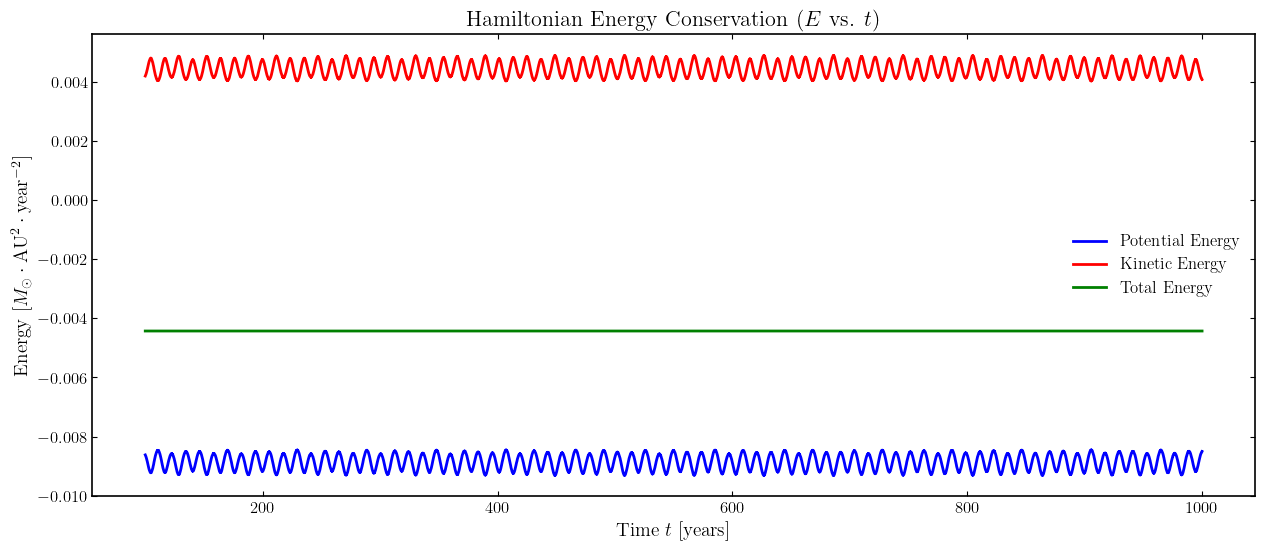

In [23]:
# --- VISUALIZATION CONTROLS ---
start_year = 100    # Start year
end_year = 1000     # End year
step = 100         # Sampling step to keep the plot fluid

# Convert years to array indices using dt_const
start_idx = int(start_year / dt_const)
end_idx = int(end_year / dt_const)

# Plot
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(time_array[start_idx:end_idx:step], Ev[start_idx:end_idx:step], "b-", label="Potential Energy")
ax.plot(time_array[start_idx:end_idx:step], Et[start_idx:end_idx:step], "r-", label="Kinetic Energy")
ax.plot(time_array[start_idx:end_idx:step], Ht[start_idx:end_idx:step], "g-", label="Total Energy")

ax.set_xlabel(r"$\text{Time } t \text{ [years]}$")
ax.set_ylabel(r"$\text{Energy } [M_{\odot} \cdot \text{AU}^2 \cdot \text{year}^{-2}]$")
ax.set_title(r"$\text{Hamiltonian Energy Conservation } (E \text{ vs. } t)$")

ax.legend(loc="best")
plt.show()

### Relative Energy Error (Hamiltonian Residual)

To rigorously evaluate the accuracy and conservation properties of the symplectic integrator, we compute the relative energy error (or Hamiltonian residual) over time:

$$
\Delta H_{\text{rel}}(t) = \frac{H(t) - H(t_0)}{H(t_0)} \times 100\%
$$

This dimensionless metric quantifies the deviations from the theoretical conservation of total energy throughout the simulation.

In [ ]:
H_residual = ((Ht - Ht[0]) / Ht[0]) * 100

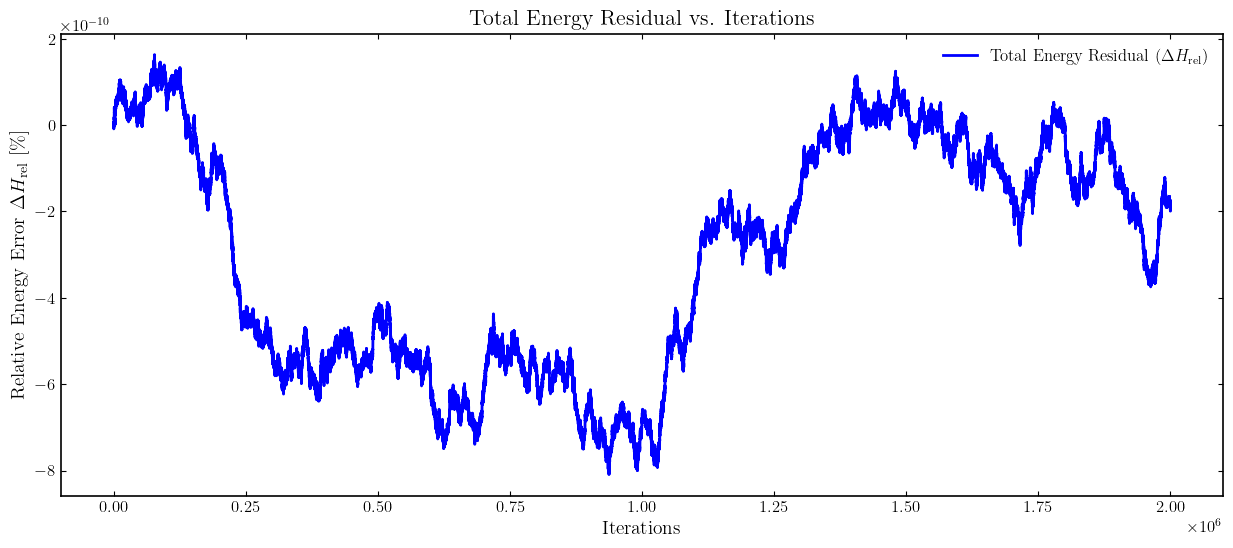

In [24]:
t = 20000
step = 10
maxi = 20_000_000

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(H_residual[:maxi:step], "b-", label=r"$\text{Total Energy Residual } (\Delta H_{\text{rel}})$")

# LaTeX formatting for axes and titles
ax.set_xlabel(r"$\text{Iterations}$")
ax.set_ylabel(r"$\text{Relative Energy Error } \Delta H_{\text{rel}} \ [\%]$")
ax.set_title(r"$\text{Total Energy Residual vs. Iterations}$")

ax.legend(loc="best")
plt.show()